# 04: Random Forest Model Development (Price Prediction)


This notebook follows the same simple structure as Notebook 03 (Linear Regression), but replaces the model with **Random Forest Regressor**.

Included:
- Train/test split (chronological)
- Standard cross validation (K-Fold)
- Time series cross validation (TimeSeriesSplit)
- Exhaustive grid search for hyperparameter tuning


In [36]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [37]:
# Load feature definitions from Notebook 01 output
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)

feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

In [38]:
# Load feature definitions from Notebook 01 output
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)

feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

In [39]:
# Train/test split (chronological) — same approach as Notebook 03
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Configured target:", target_col)
print("Configured features:", feature_cols)
print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")


Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14']
Train rows: 977
Test rows:  245
Train period: 2021-05-28 -> 2025-04-17
Test period:  2025-04-21 -> 2026-04-10


In [40]:
def regression_metrics(y_true, y_pred, model_name: str) -> pd.DataFrame:
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    return pd.DataFrame([metrics]).round(4)


In [41]:
# Primary model: Random Forest (baseline)
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=16,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

print(regression_metrics(y_train, rf_pred_train, "RandomForestRegressor (train)"))
print(regression_metrics(y_test, rf_pred_test, "RandomForestRegressor (test)"))


                           Model    MAE    RMSE    MAPE      R2
0  RandomForestRegressor (train)  1.234  1.8205  0.0071  0.9968
                          Model      MAE     RMSE    MAPE      R2
0  RandomForestRegressor (test)  17.9539  21.2391  0.0713  0.4021


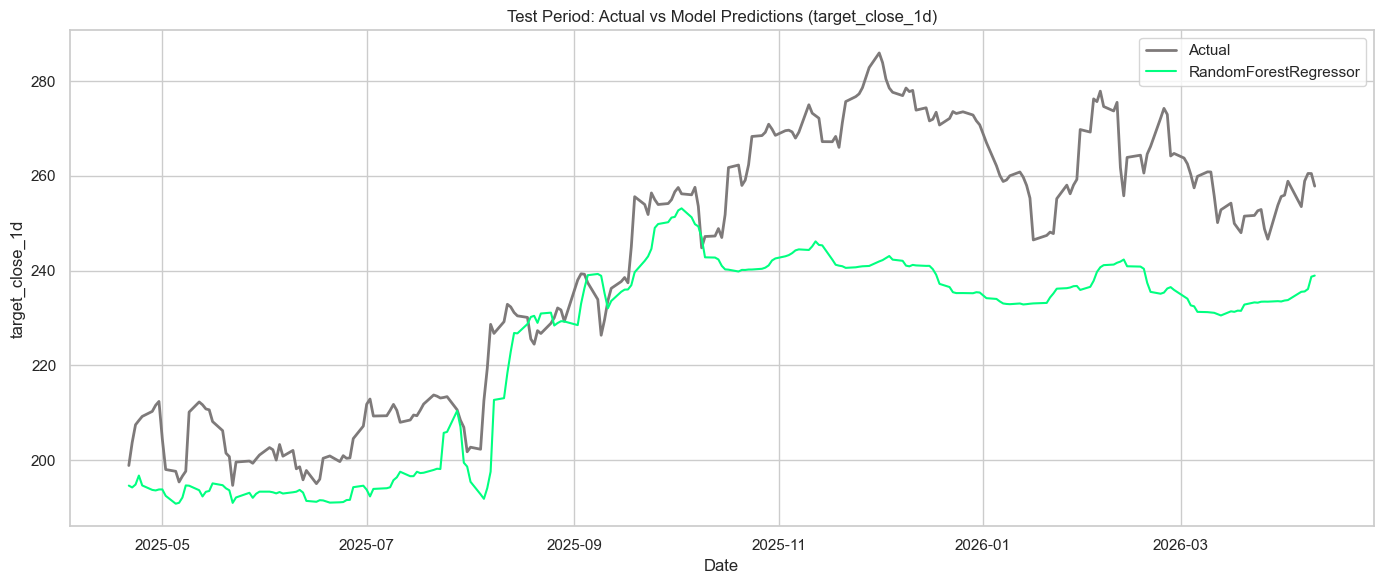

In [42]:
# Plot: Actual vs predictions
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["RandomForestRegressor"] = rf_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["RandomForestRegressor"], label="RandomForestRegressor", color="#00FF80")
plt.title(f"Test Period: Actual vs Model Predictions ({target_col})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


## Exhaustive Grid Search (Hyperparameter Tuning)

Grid search is run on the **training period only**, using **TimeSeriesSplit** for tuning.

Hyperparameters tuned and what they control:
- `n_estimators`: Number of trees. More trees usually reduce variance but increase training time.
- `max_depth`: Maximum depth of each tree. Lower values reduce overfitting risk.
- `min_samples_split`: Minimum samples needed to split a node. Higher values make trees less complex.
- `min_samples_leaf`: Minimum samples required at a leaf node. Higher values smooth predictions.
- `max_features`: Number/fraction of features considered at each split. Smaller values increase randomness.
- `bootstrap`: Whether each tree is trained on a bootstrap sample (`True`) or full data (`False`).

Grid scale design (coarse-to-fine):
- Uses roughly multiplicative steps (e.g., 200 -> 500 -> 1000 trees).
- Covers shallow-to-deeper trees and stronger leaf/split regularization.
- Keeps total combinations practical for time-series CV.

References:
- RandomForestRegressor API: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- Random Forest user guide: https://scikit-learn.org/stable/modules/ensemble.html#forest


In [43]:
base_estimator = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
)

param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", 0.5],
    "bootstrap": [True],
}

grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best CV RMSE:", -grid.best_score_)
grid.best_params_


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV RMSE: 12.942666706491408


{'bootstrap': True, 'n_estimators': 1000}

In [44]:
# Top configurations (by CV RMSE)
results_df = pd.DataFrame(grid.cv_results_)
results_df["rmse"] = -results_df["mean_test_score"]

cols = ["rmse", "mean_fit_time", "params"]
results_df.sort_values("rmse", ascending=True)[cols].head(10)


,rmse,mean_fit_time,params
2,12.942667,2.266514,"{'bootstrap': True, 'n_estimators': 1000}"
1,12.949126,1.125176,"{'bootstrap': True, 'n_estimators': 500}"
0,12.979975,0.475376,"{'bootstrap': True, 'n_estimators': 200}"


In [45]:
# Final model (best params) - evaluate on the held-out test period
best_rf = grid.best_estimator_
best_pred_test = best_rf.predict(X_test)

regression_metrics(y_test, best_pred_test, "RandomForestRegressor (tuned via TimeSeriesSplit)")


,Model,MAE,RMSE,MAPE,R2
0,RandomForestRegressor (tuned via TimeSeriesSplit),18.1838,21.39,0.0723,0.3936


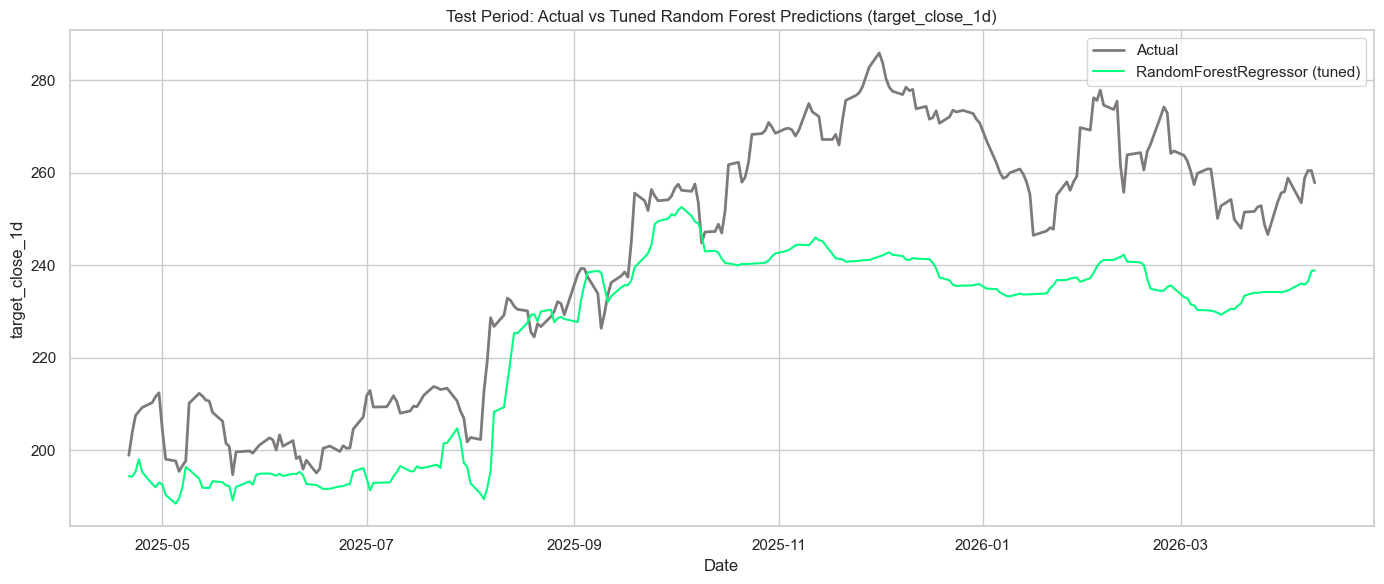

In [46]:
# Plot: Actual vs tuned model predictions
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["RandomForestRegressor_Tuned"] = best_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["RandomForestRegressor_Tuned"], label="RandomForestRegressor (tuned)", color="#00FF80")
plt.title(f"Test Period: Actual vs Tuned Random Forest Predictions ({target_col})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


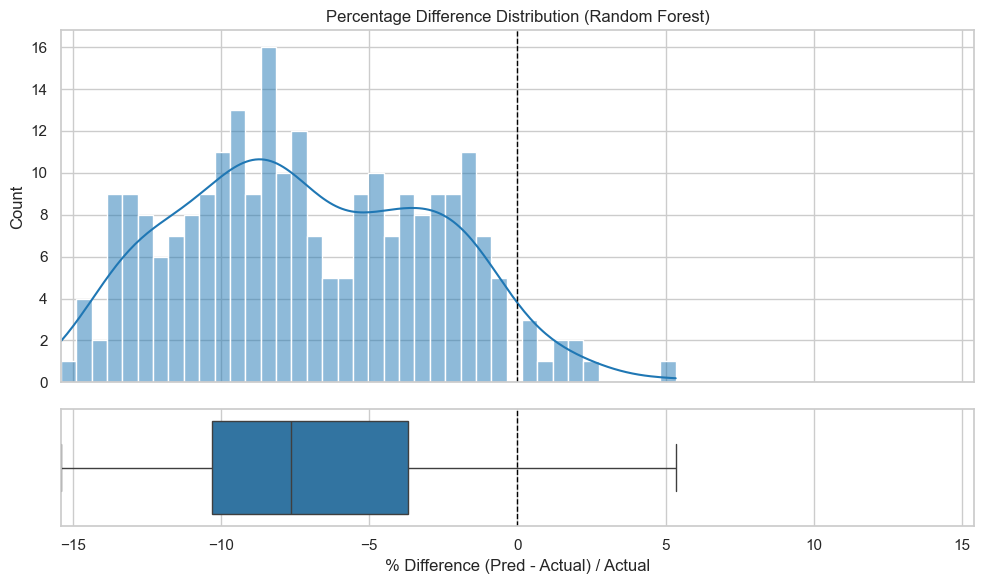

In [47]:
y_test_arr = np.asarray(y_test)
best_pred_arr = np.asarray(best_pred_test)
pct_diff = np.where(y_test_arr != 0, ((best_pred_arr - y_test_arr) / y_test_arr) * 100, np.nan)

valid_pct_diff = pct_diff[~np.isnan(pct_diff)]
if valid_pct_diff.size == 0:
    valid_pct_diff = np.array([0.0])
abs_limit = np.max(np.abs(valid_pct_diff))
if abs_limit == 0:
    abs_limit = 1

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(valid_pct_diff, bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Percentage Difference Distribution (Random Forest)")
axes[0].set_ylabel("Count")

sns.boxplot(x=valid_pct_diff, ax=axes[1], color="#1f77b4")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("% Difference (Pred - Actual) / Actual")

axes[0].set_xlim(-abs_limit, abs_limit)
axes[1].set_xlim(-abs_limit, abs_limit)

plt.tight_layout()
plt.show()


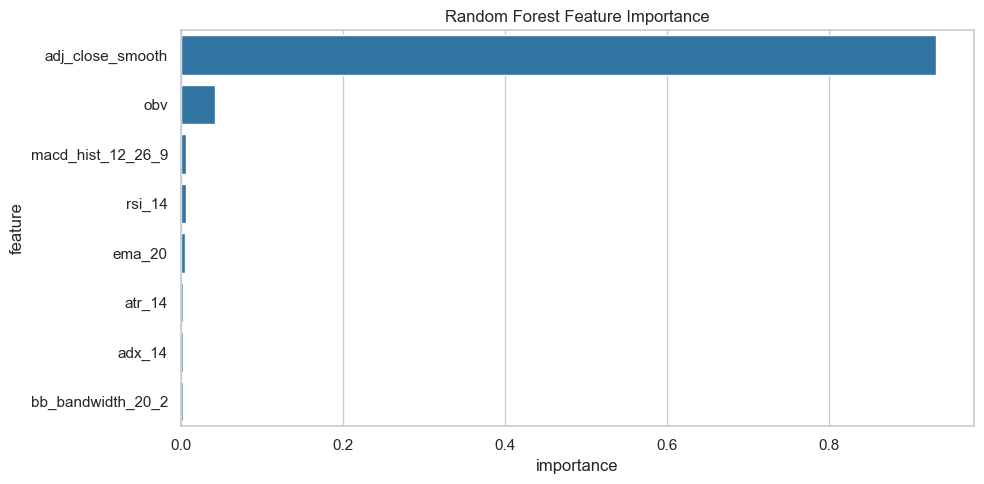

,feature,importance
5,adj_close_smooth,0.932245
4,obv,0.041940
1,macd_hist_12_26_9,0.006461
0,rsi_14,0.006053
6,ema_20,0.004689
7,atr_14,0.003024
3,adx_14,0.002924
2,bb_bandwidth_20_2,0.002664


In [48]:
# Feature importance via scikit API
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_rf.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi, x="importance", y="feature", color="#1f77b4")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

fi
